# For the BrainHack course project - fMRI connectivity matrix mapping

In [3]:
#The sleepy group

In [5]:
!pip install nilearn

In [7]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from nilearn import image, plotting
from nilearn.maskers import NiftiMapsMasker, NiftiLabelsMasker
from nilearn.connectome import ConnectivityMeasure
from nilearn import datasets

In [9]:
from pathlib import Path
# Set this to path of where dataset is stored
dataset_root = Path("/Users/Gaithtry/Downloads/brain_hack/data_files/rest_sleep_processed")

func_file = dataset_root / "sub-01_task-rest_run-1_processed.nii.gz"

print("Using:", func_file)

Using: /Users/Gaithtry/Downloads/brain_hack/data_files/rest_sleep_processed/sub-01_task-rest_run-1_processed.nii.gz


In [11]:
### Shaefer Atals
atlas_dataset = datasets.fetch_atlas_schaefer_2018(data_dir=dataset_root, n_rois=400, yeo_networks=7)
atlas_filepath = atlas_dataset.maps
atlas_labels = atlas_dataset.labels[1:]

atlas_masker = NiftiLabelsMasker(
    labels_img=atlas_dataset.maps,
    standardize=True, # Z-scores the time series
    detrend=True,
    #high_pass=0.009, low_pass=0.08, t_r=2.1 # Adjust TR to your data
)

atlas_masker.fit()

[fetch_atlas_schaefer_2018] Dataset found in 
/Users/Gaithtry/Downloads/brain_hack/data_files/rest_sleep_processed/schaefer_2018

NiftiLabelsMasker(detrend=True,
                  labels_img='/Users/Gaithtry/Downloads/brain_hack/data_files/rest_sleep_processed/schaefer_2018/Schaefer2018_400Parcels_7Networks_order_FSLMNI152_1mm.nii.gz',
                  standardize=True)

In [13]:
correlation_measure = ConnectivityMeasure(kind="correlation")

def compute_connectivity(func_file):
    fmri_img = image.load_img(func_file)
    timeseries = atlas_masker.transform(fmri_img)
    matrix = correlation_measure.fit_transform([timeseries])[0]
    
    return timeseries, matrix

In [15]:
def plot_connectivity_matrix(matrix, labels, title="Connectivity Matrix"):
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(matrix, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_yticklabels(labels, fontsize=7)
    plt.colorbar(im, ax=ax, label="Pearson r")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

In [17]:
timeseries, matrix = compute_connectivity(func_file)

/var/folders/fs/j7mzyn0108nf8c8x6ny97trc0000gq/T/ipykernel_5748/1265877012.py:5: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  timeseries = atlas_masker.transform(fmri_img)
/var/folders/fs/j7mzyn0108nf8c8x6ny97trc0000gq/T/ipykernel_5748/1265877012.py:5: UserWarning: Resampling labels at transform time...
To avoid this warning, make sure to pass the images you want to transform to fit() first, or directly use fit_transform().
  timeseries = atlas_masker.transform(fmri_img)
/var/folders/fs/j7mzyn0108nf8c8x6ny97trc0000gq/T/ipykernel_5748/1265877012.py:6: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample 

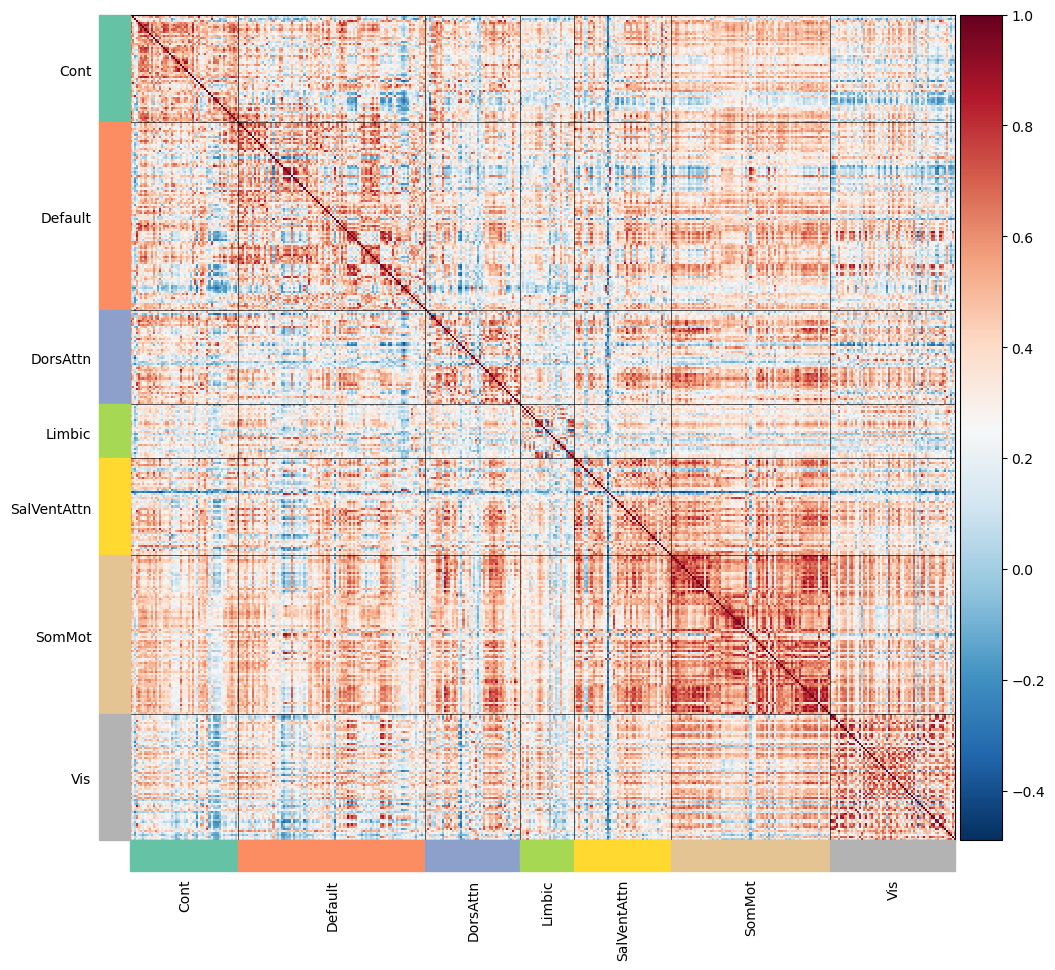

In [20]:
#plotting the atlas labels

import matplotlib.pyplot as plt
import numpy as np
from nilearn import plotting
from itertools import groupby

network_assignments = [label.decode('utf-8').split('_')[2] if isinstance(label, bytes) else label.split('_')[2] for label in atlas_labels]
sort_idx = np.argsort(network_assignments)

ordered_matrix = matrix[sort_idx, :][:, sort_idx]
ordered_labels = [network_assignments[i] for i in sort_idx]

#count and summarize labels for axis purposes
unique_networks = []
network_sizes = []
for k, g in groupby(ordered_labels):
    unique_networks.append(k)
    network_sizes.append(sum(1 for _ in list(g)))

#establish label boundaries 
boundaries = np.insert(np.cumsum(network_sizes), 0, 0)
tick_positions = [(boundaries[i] + boundaries[i+1]) / 2 for i in range(len(boundaries) - 1)]

#plot matrix
display = plotting.plot_matrix(
    ordered_matrix,
    figure=(10, 10),
    colorbar=True,
    reorder=False
)

#matrix axes
ax = display.axes

# boundary lines inside axis
colors = plt.cm.Set2(np.linspace(0, 1, len(network_sizes)))
for i in range(1, len(boundaries) - 1):
    ax.axvline(boundaries[i] - 0.5, color="black", linewidth=0.5, alpha=0.9)
    ax.axhline(boundaries[i] - 0.5, color="black", linewidth=0.5, alpha=0.9)
    
bar_width = 15 
matrix_size = ordered_matrix.shape[0]

# colored bars along the edges
for i in range(len(boundaries) - 1):
    start, end = boundaries[i], boundaries[i+1]
    current_color = colors[i]
    
    # Left edge color bar (Y-axis tracking)
    ax.axhspan(start - 0.5, end - 0.5, xmin=-bar_width/matrix_size, xmax=0, 
               color=current_color, clip_on=False, zorder=3)
    
    # Bottom edge color bar (X-axis tracking)
    ax.axvspan(start - 0.5, end - 0.5, ymin=-bar_width/matrix_size, ymax=0, 
               color=current_color, clip_on=False, zorder=3)

ax.tick_params(axis='both', which='both', length=18, pad=10, direction='out')

# labels 
ax.set_xticks(tick_positions)
ax.set_xticklabels(unique_networks, rotation=90, fontsize=10)

ax.set_yticks(tick_positions)
ax.set_yticklabels(unique_networks, fontsize=10)

plt.show()

In [21]:
print(raw_labels[:10])

['Background', '7Networks_LH_Vis_1', '7Networks_LH_Vis_2', '7Networks_LH_Vis_3', '7Networks_LH_Vis_4', '7Networks_LH_Vis_5', '7Networks_LH_Vis_6', '7Networks_LH_Vis_7', '7Networks_LH_Vis_8', '7Networks_LH_Vis_9']
